# Maintaining case bases through energy

## Step 1: Imports and data loading
First, we need to import:
- `numpy`
- `matplotlib.pyplot` to draw the plots
- `sklearn` to have the data and decision boundary display utilities

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.preprocessing import StandardScaler, QuantileTransformer

Then, we import the `meatcube2` package to obtain the models

In [3]:
# as the code is loaded from a subfolder, we use the following snippet to add meatcube2 to the import path
# for a normal usage with meatcube2 installed, the two following lines are unnecessary
import sys, os
try:
    current_folder = os.path.dirname(__file__) # normal way
except NameError:
    current_folder = globals()['_dh'][0] # jupyter notebook way
sys.path.append(os.path.join(current_folder, '../..'))

# we load meatcube2 
from meatcube2.models import MeATCubeCB, CtCoAT, CtCoATNaive, EnergyKNN
from meatcube2.plotting.compare import animate_dataset_model_grid_on_models, split_datasets
from meatcube2.cb_maintenance import CBClassificationMaintainer


We also import `scipy` to define some similarity measures:

In [4]:
from scipy.linalg import norm
from scipy.spatial.distance import euclidean, cosine, correlation, braycurtis, hamming
def euclidean_sim(x1,x2):
    return np.exp(-euclidean(x1,x2))
def cosine_sim(x1,x2):
    return np.exp(-cosine(x1,x2))
def correlation_sim(x1,x2):
    return np.exp(-correlation(x1,x2))
def hamming_sim(x1,x2):
    return np.exp(-hamming(x1,x2))
def radius_sim(x1,x2):
    return np.exp(-abs(norm(x1)-norm(x2)))
def class_equality_sim(y1,y2):
    return np.equal(y1,y2).astype(float)

Finally, we can load the data (here we use some `sklearn` artificial datasets, but anything goes):

In [5]:
from sklearn.datasets import make_circles, make_classification, make_moons

N_SAMPLES = 100

# some linearly separable data with added noise
X, y = make_classification(
    n_features=2, n_redundant=0, n_informative=2, random_state=1, n_clusters_per_class=1, n_samples=N_SAMPLES
)
rng = np.random.RandomState(2)
X += 2 * rng.uniform(size=X.shape)
linearly_separable = (X, y)


# our three datasets
dataset_names = [
    "Moons",
    "Circles",
    "Line",
]
datasets = [
    make_moons(noise=0.3, random_state=0, n_samples=N_SAMPLES),
    make_circles(noise=0.2, factor=0.5, random_state=1, n_samples=N_SAMPLES),
    linearly_separable,
]

## Step 2: Defining the models

In [6]:

names = [
    "MeATCube \n($\sigma_X$: Euclidean, $\sigma_y$: class)",
    # "MeATCube \n($\sigma_X$: Cosine, $\sigma_y$: class)",
    # # "MeATCube \n($\sigma_X$: Radius w.r.t (0, 0), $\sigma_y$: class)",
    # "MeATCube \n($\sigma_X$: Correlation, $\sigma_y$: class)",
    # "MeATCube \n($\sigma_X$: Hamming, $\sigma_y$: class)",
    "CtCoat \n($\sigma_X$: Euclidean, $\sigma_y$: class)",
    "1NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)",
    "3NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)",
    "10NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)",
]

classifiers = [
    MeATCubeCB(euclidean_sim, class_equality_sim, precompute_sim_matrix=True),
    # MeATCubeCB(cosine_sim, class_equality_sim, precompute_sim_matrix=True),
    # # MeATCubeCB(radius_sim, class_equality_sim),
    # MeATCubeCB(correlation_sim, class_equality_sim, precompute_sim_matrix=True),
    # MeATCubeCB(hamming_sim, class_equality_sim, precompute_sim_matrix=True),
    CtCoAT(euclidean_sim, class_equality_sim, precompute_sim_matrix=True),
    # CtCoAT(euclidean_sim, class_equality_sim, normalize=False),
    EnergyKNN(euclidean_sim, class_equality_sim, n_neighbors=1, precompute_sim_matrix=True),
    EnergyKNN(euclidean_sim, class_equality_sim, n_neighbors=3, precompute_sim_matrix=True),
    EnergyKNN(euclidean_sim, class_equality_sim, n_neighbors=10, precompute_sim_matrix=True),

]

# dataset, dataset_name = datasets[:1], dataset_names[:1]
# dataset_split = split_datasets(dataset, True)
# (X_train, y_train), (X_ref, y_ref), (X_test, y_test) = dataset_split[0]

## Step 3: Performing maintenance by compression

### Performing basic compression process

In [7]:
dataset, dataset_name = datasets[:1], dataset_names[:1]
dataset_split = split_datasets(dataset, True)
(X_train, y_train), (X_ref, y_ref), (X_test, y_test) = dataset_split[0]

In [8]:
maintainer = CBClassificationMaintainer(
    MeATCubeCB(euclidean_sim, class_equality_sim, precompute_sim_matrix=True),
    #CtCoAT(euclidean_sim, class_equality_sim, precompute_sim_matrix=True),
    #EnergyKNN(euclidean_sim, class_equality_sim, precompute_sim_matrix=True),
    memorize_estimators=True,
    patience=-1)
maintainer.fit(X_train, y_train, X_ref, y_ref)

### Animating the compression process

In [9]:
from IPython.display import HTML
ani, _, _= animate_dataset_model_grid_on_models(
    dataset_split,
    dataset_name,
    maintainer.estimators_,
    classifiers_names=[f"step {i}\n(accuracy on ref set: {maintainer.scores_[i]:.3%})" for i in range(len(maintainer.estimators_))],
    fit_estimators=False,
    progress_bar=False,
    size_as_decrement_score=True)#"notebook")
#plt.show()

# To save the animation using Pillow as a gif
import matplotlib.animation as animation
writer = animation.PillowWriter(fps=2,
                                metadata=dict(artist='Me'),
                                bitrate=1800)
ani.save('demo_maintenance.gif', writer=writer)

html = HTML(ani.to_jshtml())
plt.clf()
html

/home/emarquer/Repositories/MeATCube/examples/meatcube2/../../meatcube2/plotting/compare.py:267: RuntimeWarning: invalid value encountered in divide
  s = ((sizes - sizes.min()) / (sizes.max() - sizes.min())) * 20 + 10
/home/emarquer/Repositories/MeATCube/examples/meatcube2/../../meatcube2/plotting/compare.py:267: RuntimeWarning: invalid value encountered in divide
  s = ((sizes - sizes.min()) / (sizes.max() - sizes.min())) * 20 + 10
/home/emarquer/Repositories/MeATCube/examples/meatcube2/../../meatcube2/plotting/compare.py:267: RuntimeWarning: invalid value encountered in divide
  s = ((sizes - sizes.min()) / (sizes.max() - sizes.min())) * 20 + 10
/home/emarquer/Repositories/MeATCube/examples/meatcube2/../../meatcube2/plotting/compare.py:267: RuntimeWarning: invalid value encountered in divide
  s = ((sizes - sizes.min()) / (sizes.max() - sizes.min())) * 20 + 10


<Figure size 600x300 with 0 Axes>

<!--![demo_maintenance.gif](demo_maintenance.gif)-->

### Comparing the performance of different models through compression

In [10]:
from meatcube2.metrics import confidence, clf_prediction_summary
dfs = dict()

for dataset, dataset_name in zip(split_datasets(datasets, True), dataset_names):
    (X_train, y_train), (X_ref, y_ref), (X_test, y_test) = dataset
    # define a custom metric to account for the test set performance
    def test_ref_clf_prediction_summary(cb, X_ref, y_ref):
        scores = {
            "ref_"+k: v for k, v in clf_prediction_summary(cb, X_ref, y_ref).items()
        }
        scores.update({
            "test_"+k: v for k, v in clf_prediction_summary(cb, X_test, y_test).items()
        })
        return scores
    for model, model_name in zip(classifiers, names):
        print(model_name, dataset_name)
        maintainer = CBClassificationMaintainer(
            model,
            memorize_estimators=True,
            scoring=test_ref_clf_prediction_summary,
            refit="ref_accuracy",
            patience=-1)
        maintainer.fit(X_train, y_train, X_ref, y_ref)
        
        df_ = pd.DataFrame.from_records(maintainer.results_)
        #df_["dataset"] = dataset_name
        dfs[(model_name, dataset_name)] = df_

MeATCube 
($\sigma_X$: Euclidean, $\sigma_y$: class) Moons
CtCoat 
($\sigma_X$: Euclidean, $\sigma_y$: class) Moons
1NN 
($\sigma_X$: Euclidean, $\sigma_y$: class) Moons
3NN 
($\sigma_X$: Euclidean, $\sigma_y$: class) Moons
10NN 
($\sigma_X$: Euclidean, $\sigma_y$: class) Moons
MeATCube 
($\sigma_X$: Euclidean, $\sigma_y$: class) Circles
CtCoat 
($\sigma_X$: Euclidean, $\sigma_y$: class) Circles
1NN 
($\sigma_X$: Euclidean, $\sigma_y$: class) Circles
3NN 
($\sigma_X$: Euclidean, $\sigma_y$: class) Circles
10NN 
($\sigma_X$: Euclidean, $\sigma_y$: class) Circles
MeATCube 
($\sigma_X$: Euclidean, $\sigma_y$: class) Line
CtCoat 
($\sigma_X$: Euclidean, $\sigma_y$: class) Line
1NN 
($\sigma_X$: Euclidean, $\sigma_y$: class) Line
3NN 
($\sigma_X$: Euclidean, $\sigma_y$: class) Line
10NN 
($\sigma_X$: Euclidean, $\sigma_y$: class) Line


In [11]:
df = pd.concat(dfs).reset_index(level=[0, 1], names=["model", "dataset"])
df.to_pickle("maintenance_result_.pkl")

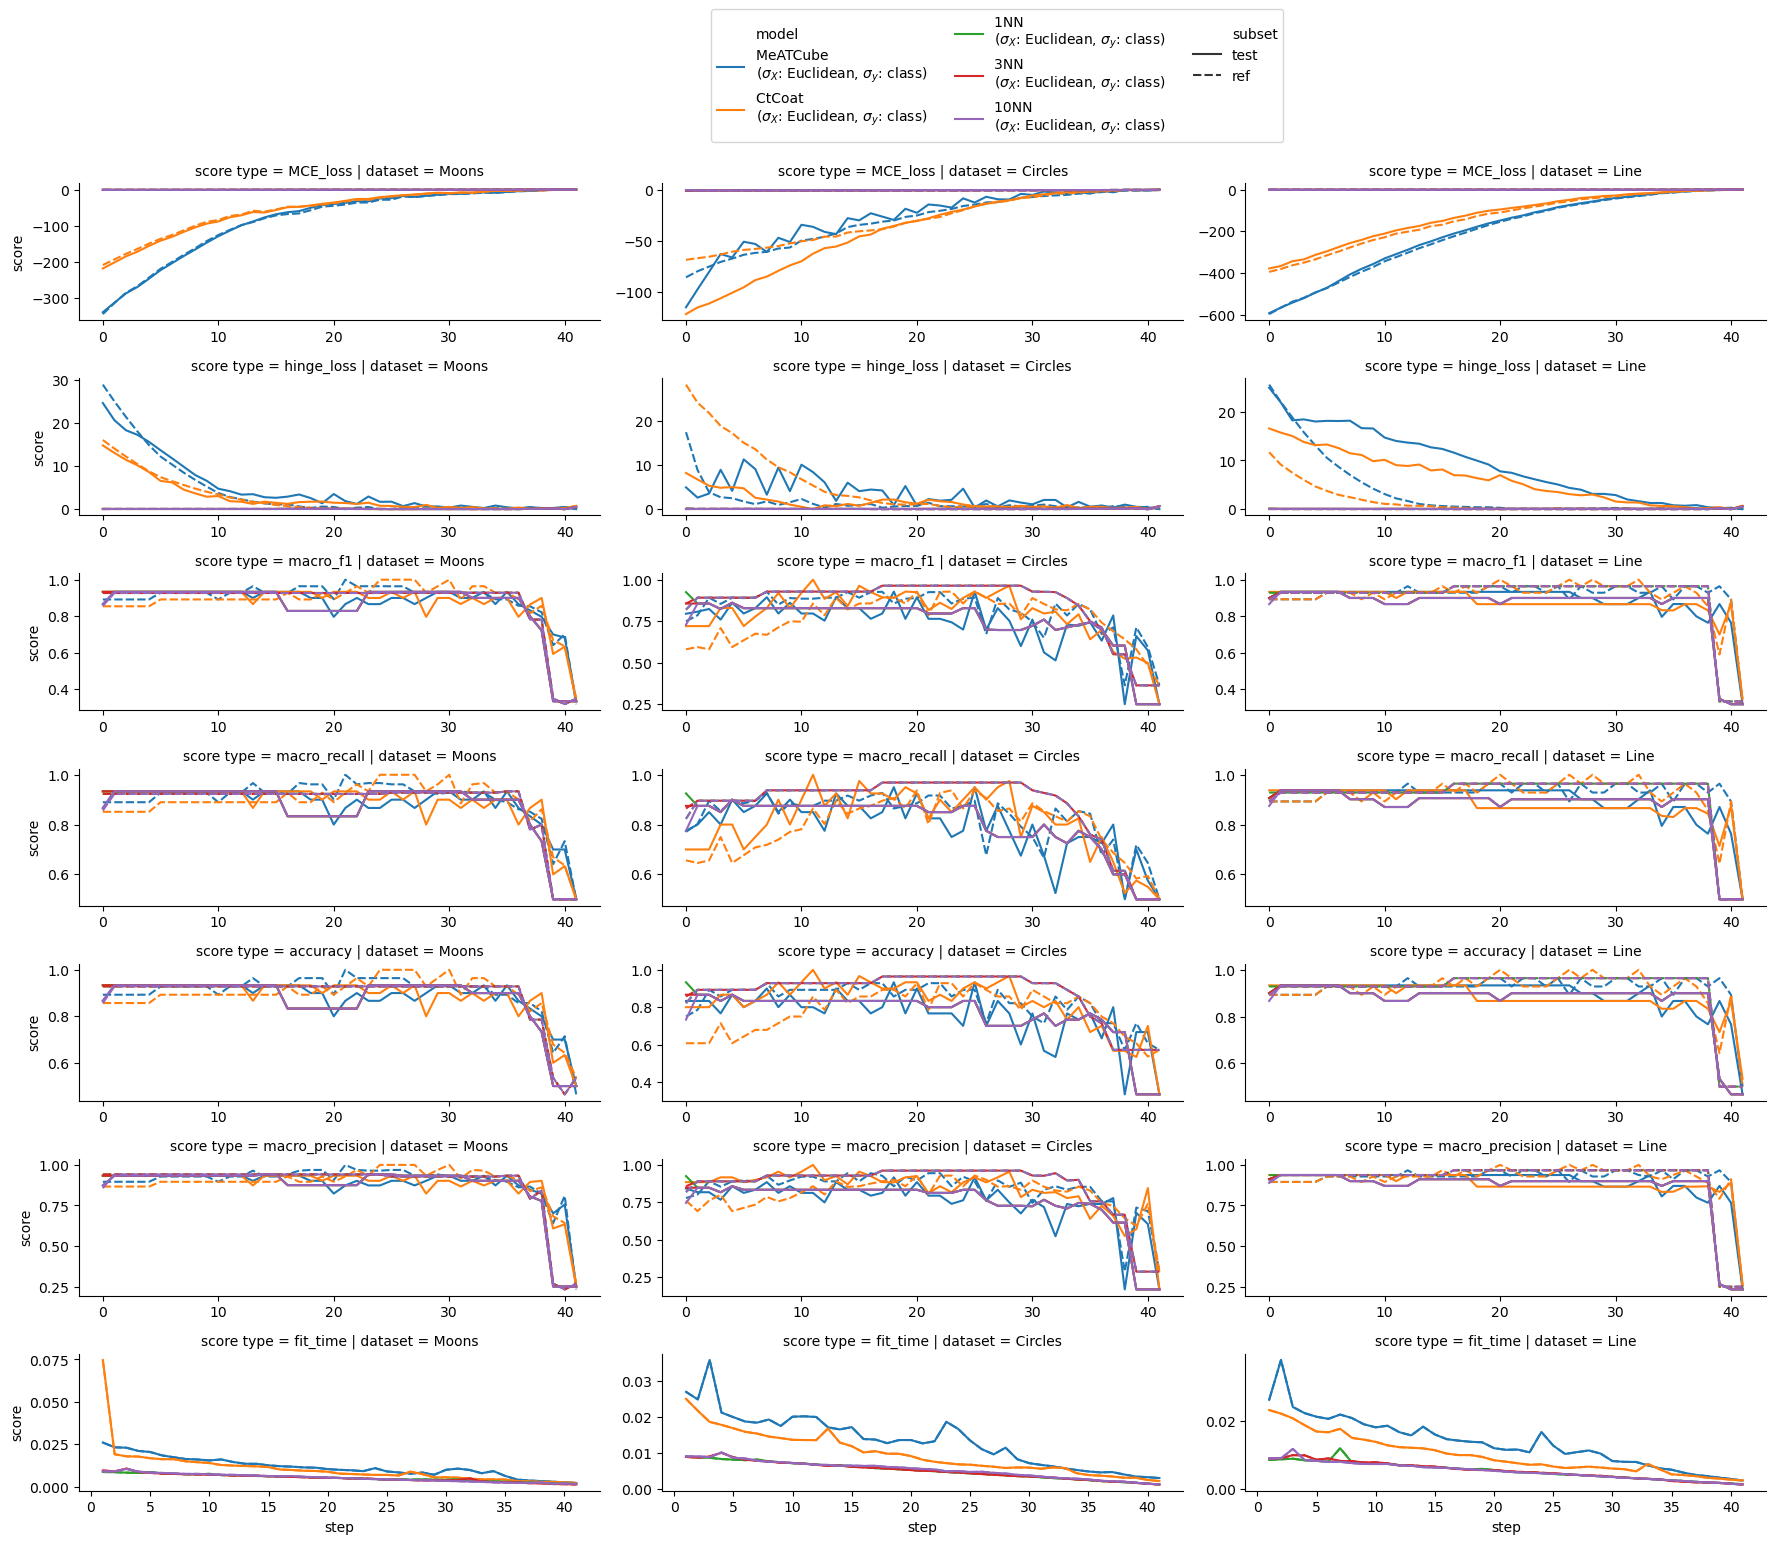

In [12]:
value_vars = ["MCE_loss", "hinge_loss", "macro_f1", "macro_recall", "accuracy", "macro_precision"]
invariant_value_vars = ["fit_time"]

df_ = df.copy()
df_["k"] = 0
df_.loc[df_["model"].str.contains("1NN"),"k"] = 1
df_.loc[df_["model"].str.contains("3NN"),"k"] = 3
df_.loc[df_["model"].str.contains("10NN"),"k"] = 10
# for var in value_vars:
#     for subset in ["test", "ref"]:
#         if (df_[subset+"_"+var] > 0).any():
#             g_df = df_.fillna(0).groupby(["model", "dataset", "k"], group_keys=True, dropna=False)[subset+"_"+var].max().reset_index()
#         else:
#             g_df = df_.fillna(0).groupby(["model", "dataset", "k"], group_keys=True, dropna=False)[subset+"_"+var].min().reset_index()
#         df_[subset+"_"+var+"%"] = df_.fillna(0).apply(
#             lambda row: row[subset+"_"+var] / (g_df[
#                 (g_df["model"] == row["model"]) &
#                 (g_df["dataset"] == row["dataset"]) &
#                 (g_df["k"] == row["k"])][subset+"_"+var].item() + 1e-12)
#               , axis=1)
#         # print(g_df[["model", "dataset", "k"]])
#         # print(df_.fillna(0)[["model", "dataset", "k"]])
#         # df_.fillna(0).apply(
#         #     lambda row: print(g_df[g_df[["model", "dataset", "k"]] == row[["model", "dataset", "k"]]])
#         #       , axis=1)
df_ = pd.concat({
    subset: df_.melt(
        id_vars=["model", "step", "dataset", "k"],
        #value_vars=[subset+"_"+var+"%" for var in value_vars] + invariant_value_vars,
        value_vars=[subset+"_"+var for var in value_vars] + invariant_value_vars,
        var_name="score type",
        value_name="score")
    for subset in ["test", "ref"]})#.reset_index(level=0, names="subset", allow_duplicates=False)
df_["subset"] = df_.index.get_level_values(0)
df_["score type"] = df_["score type"].replace(
    to_replace={
        **{subset+"_"+var+"%": var+"%" for var in value_vars for subset in ["test", "ref"]},
        **{subset+"_"+var: var for var in value_vars for subset in ["test", "ref"]}
})
df_["k"] = df_["k"].replace(np.nan, 0).astype(int)
# g = sns.relplot(
#     df_[df_["dataset"]=="Moons"],
#     x = "step", y = "score",
#     row="score type", col="subset",#"dataset",
#     hue="model", style="k",
#     facet_kws={"sharey":False, "sharex":False},
#     kind="line",
#     aspect=3, height=2)
g = sns.relplot(
    df_,
    x = "step", y = "score",
    row="score type", col="dataset",
    hue="model", style="subset",
    facet_kws={"sharey":False, "sharex":False},
    kind="line",
    aspect=3, height=2)
sns.move_legend(g, "lower center", bbox_to_anchor=(.5, 1), frameon=True, ncol=3)

In [ ]:
df = pd.read_pickle(os.path.abspath(os.path.join(current_folder,"..","..","benchmark_df_.pkl")))
#df.reset_index(level=[0, 1], names=["model", "dataset"])
df = df.reset_index(level=[0, 1], names=["model_", "dataset"])

In [ ]:
value_vars = ["MCE_loss", "hinge_loss", "macro_f1", "macro_recall", "accuracy", "macro_precision"]
invariant_value_vars = ["fit_time"]

df__ = pd.json_normalize(df["parameters"].apply(lambda x: dict(x)))
#df_ = pd.concat([df, pd.json_normalize(df["parameters"].apply(lambda x: dict(x)))], axis = "columns", ignore_index=True)
df__.index=df.index
df_ = pd.concat([df, df__], axis = "columns")
for var in value_vars:
    for subset in ["test", "ref"]:
        if (df_[subset+"_"+var] > 0).any():
            g_df = df_.fillna(0).groupby(["model", "dataset", "k"], group_keys=True, dropna=False)[subset+"_"+var].max().reset_index()
        else:
            g_df = df_.fillna(0).groupby(["model", "dataset", "k"], group_keys=True, dropna=False)[subset+"_"+var].min().reset_index()
        df_[subset+"_"+var+"%"] = df_.fillna(0).apply(
            lambda row: row[subset+"_"+var] / g_df[
                (g_df["model"] == row["model"]) &
                (g_df["dataset"] == row["dataset"]) &
                (g_df["k"] == row["k"])][subset+"_"+var].item()
              , axis=1)
        # print(g_df[["model", "dataset", "k"]])
        # print(df_.fillna(0)[["model", "dataset", "k"]])
        # df_.fillna(0).apply(
        #     lambda row: print(g_df[g_df[["model", "dataset", "k"]] == row[["model", "dataset", "k"]]])
        #       , axis=1)
df_ = pd.concat({
    subset: df_.melt(
        id_vars=["model", "step", "dataset", "k"],
        #value_vars=[subset+"_"+var+"%" for var in value_vars] + invariant_value_vars,
        value_vars=[subset+"_"+var for var in value_vars] + invariant_value_vars,
        var_name="score type",
        value_name="score")
    for subset in ["test", "ref"]})#.reset_index(level=0, names="subset", allow_duplicates=False)
df_["subset"] = df_.index.get_level_values(0)
df_["score type"] = df_["score type"].replace(
    to_replace={
        **{subset+"_"+var+"%": var+"%" for var in value_vars for subset in ["test", "ref"]},
        **{subset+"_"+var: var for var in value_vars for subset in ["test", "ref"]}
})
df_["k"] = df_["k"].replace(np.nan, 0).astype(int)
g = sns.relplot(
    df_,
    x = "step", y = "score",
    row="score type", col="subset",#"dataset",
    hue="model", style="k",
    facet_kws={"sharey":False, "sharex":False},
    kind="line",
    aspect=3, height=2)
sns.move_legend(g, "lower center", bbox_to_anchor=(.5, 1), frameon=True, ncol=3)

KeyError: 'parameters'

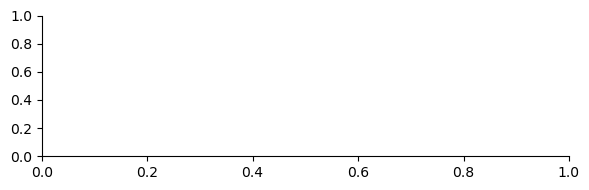

In [ ]:
df_["k"] = df_["k"].replace(np.nan, 0).astype(int)
sns.relplot(
    
df_[df_["dataset"]=="Balance Scale"],
    x = "step", y = "score",
    row="score type", col="subset",
    hue="model", style="k",
    facet_kws={"sharey":False, "sharex":False},
    kind="line",
    aspect=3, height=2)

In [ ]:
value_vars = ["MCE_loss", "hinge_loss", "macro_f1", "macro_recall", "accuracy", "macro_precision"]
invariant_value_vars = ["fit_time"]

df_ = pd.concat({
    subset: df.melt(
        id_vars=["model", "step", "dataset"],
        value_vars=[subset+"_"+var for var in value_vars] + invariant_value_vars,
        var_name="score type",
        value_name="score")
    for subset in ["test", "ref"]})#.reset_index(level=0, names="subset", allow_duplicates=False)
df_["subset"] = df_.index.get_level_values(0)
df_["score type"] = df_["score type"].replace(
    to_replace={subset+"_"+var: var for var in value_vars for subset in ["test", "ref"]})
#{subset+"_"+var: var for var in value_vars for subset in ["test", "ref"]}

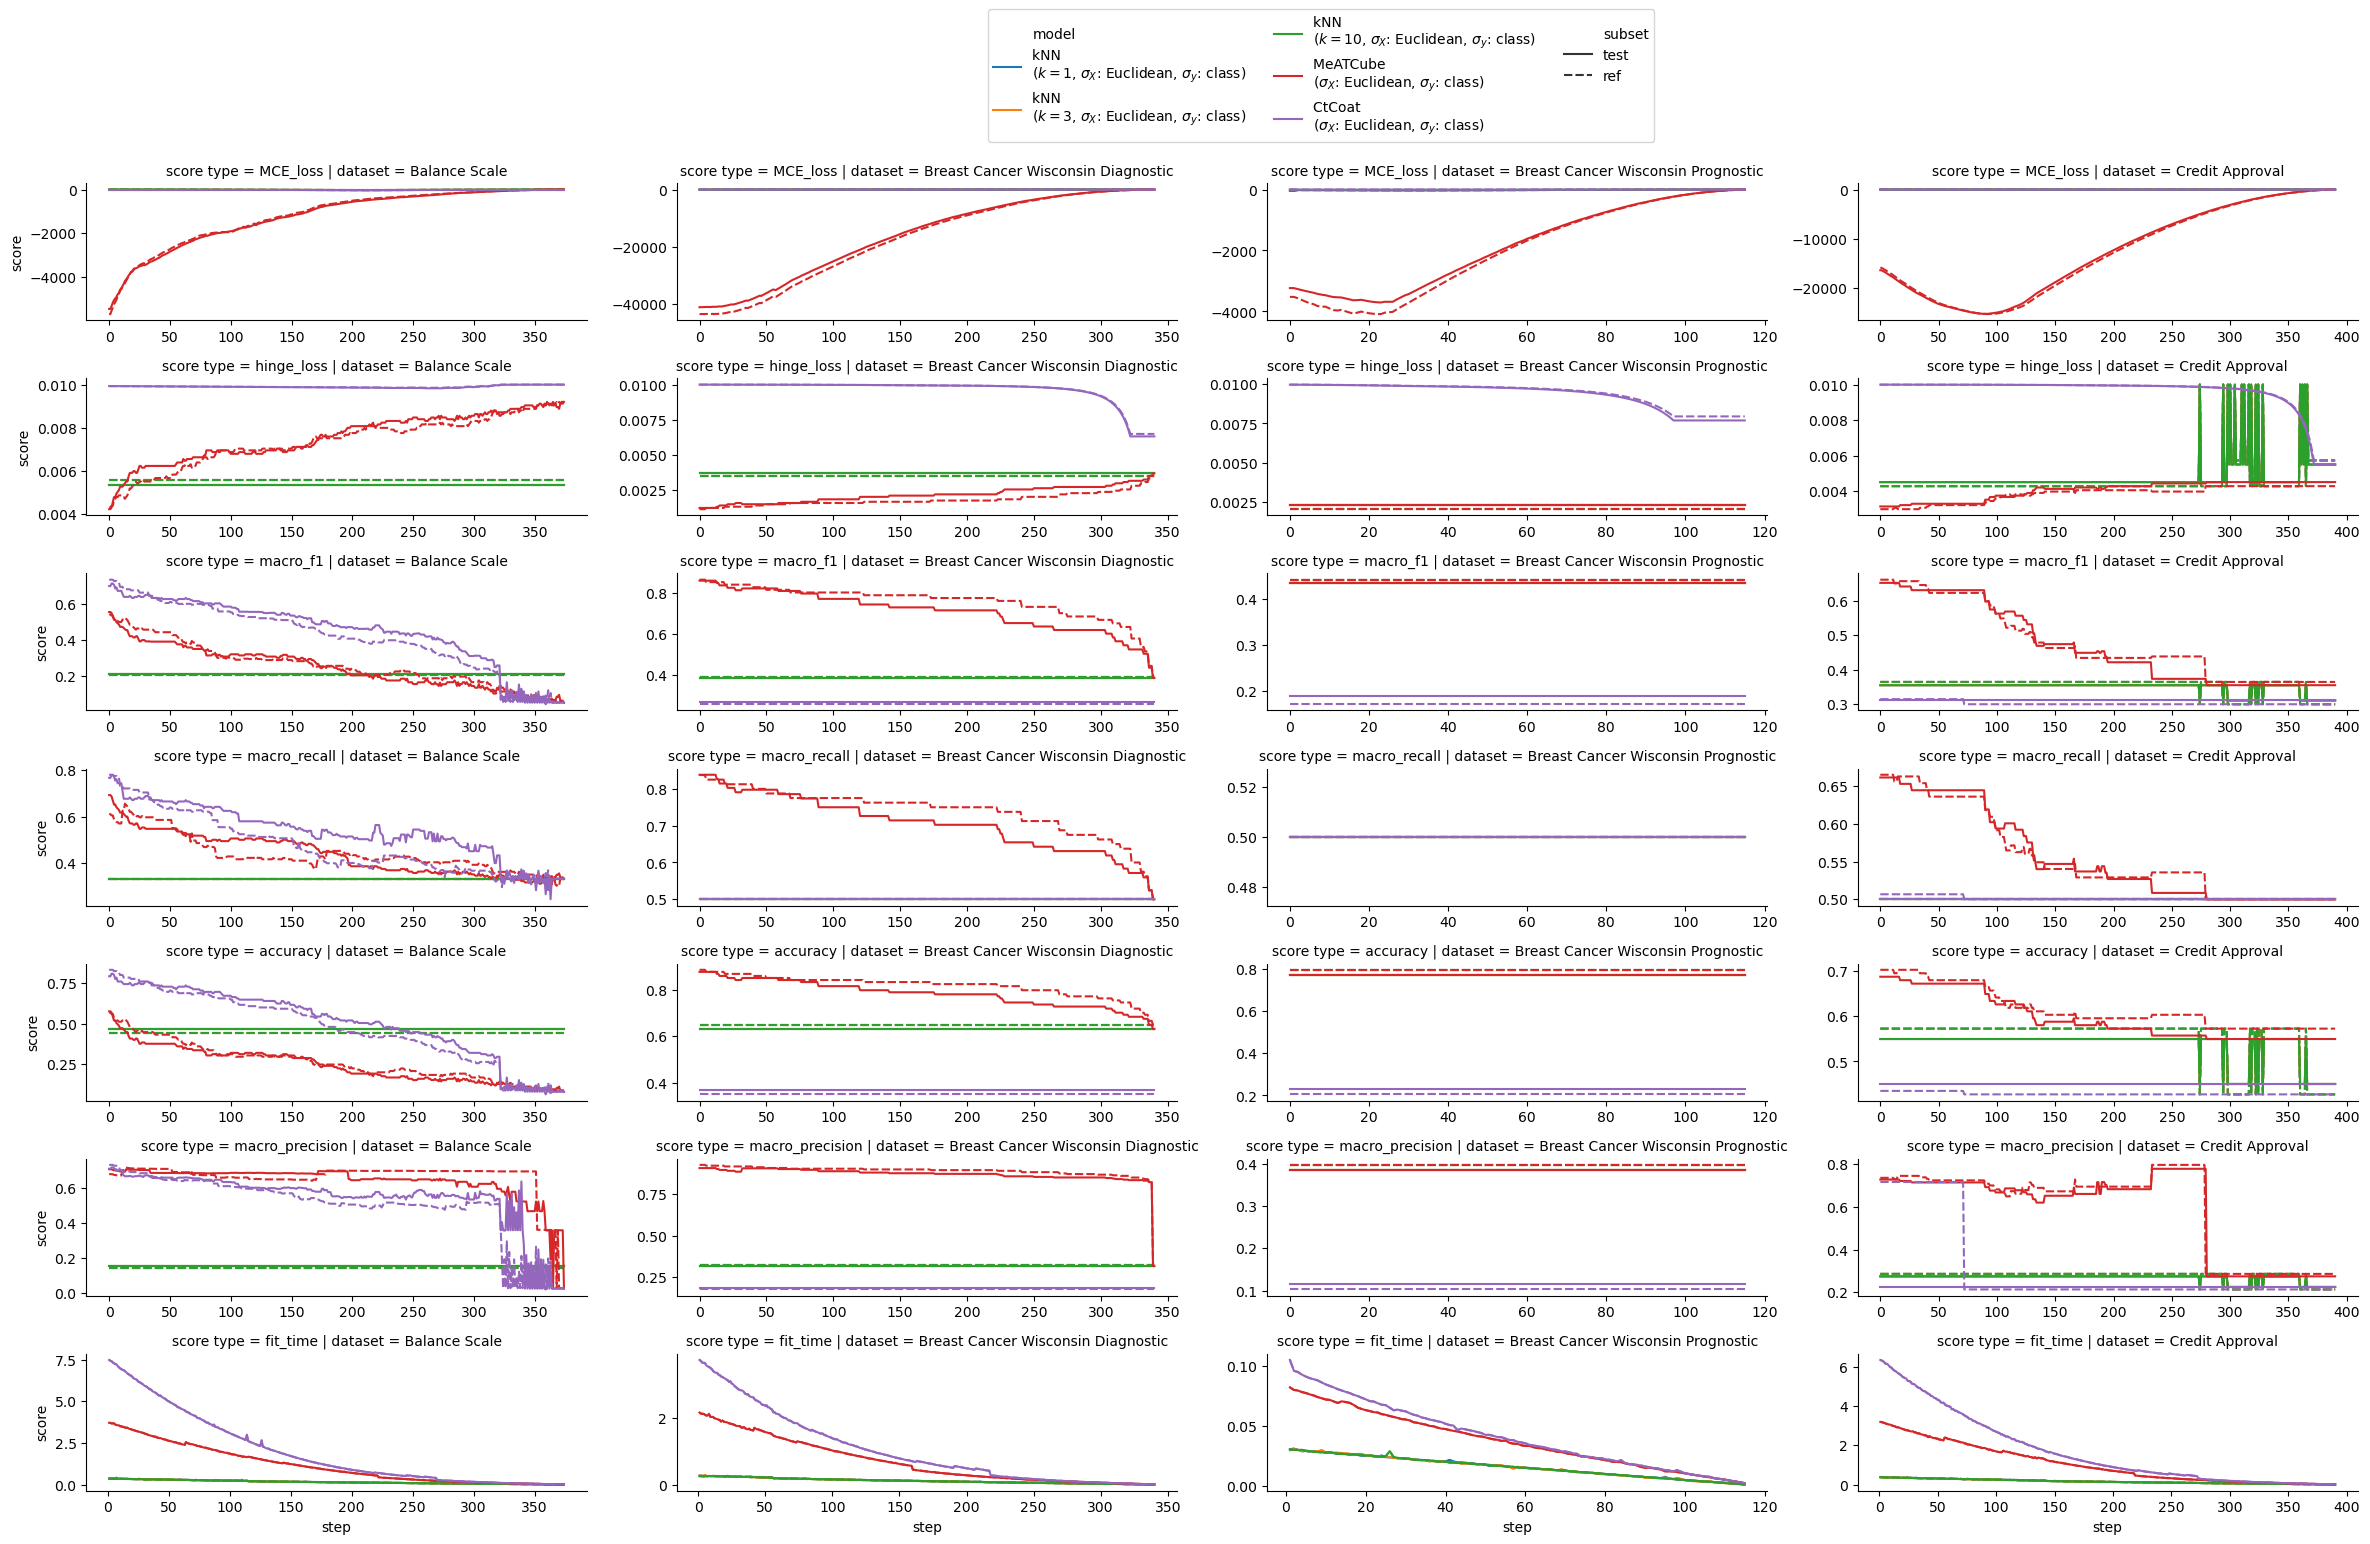

In [ ]:
g = sns.relplot(
    df_,
    x = "step", y = "score",
    row="score type", col="dataset",
    hue="model", style="subset",
    facet_kws={"sharey":False, "sharex":False},
    kind="line",
    aspect=3, height=2)
sns.move_legend(g, "lower center", bbox_to_anchor=(.5, 1), frameon=True, ncol=3)

In [ ]:
df.groupby(["dataset", "model"]).describe().loc[:,(slice(None),["mean", "std"])]

accuracy  \
                                                                mean   
dataset model                                                          
Circles 10NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)   0.876701   
        1NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)    0.876701   
        3NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)    0.877551   
        CtCoat \n($\sigma_X$: Euclidean, $\sigma_y$: cl...  0.623299   
        MeATCube \n($\sigma_X$: Euclidean, $\sigma_y$: ...  0.871599   
Line    10NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)   0.933673   
        1NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)    0.934524   
        3NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)    0.933673   
        CtCoat \n($\sigma_X$: Euclidean, $\sigma_y$: cl...  0.875850   
        MeATCube \n($\sigma_X$: Euclidean, $\sigma_y$: ...  0.909864   
Moons   10NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)   0.892857   
        1NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)    0.894558   
        3NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)    0.894558   
        CtCoat \n($\sigma_X$: Euclidean, $\sigma_y$: cl...  0.871599   
        MeATCube \n($\sigma_X$: Euclidean, $\sigma_y$: ...  0.926020   

                                                                      \
                                                                 std   
dataset model                                                          
Circles 10NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)   0.126011   
        1NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)    0.126011   
        3NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)    0.125749   
        CtCoat \n($\sigma_X$: Euclidean, $\sigma_y$: cl...  0.032716   
        MeATCube \n($\sigma_X$: Euclidean, $\sigma_y$: ...  0.080077   
Line    10NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)   0.126348   
        1NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)    0.126187   
        3NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)    0.126348   
        CtCoat \n($\sigma_X$: Euclidean, $\sigma_y$: cl...  0.062229   
        MeATCube \n($\sigma_X$: Euclidean, $\sigma_y$: ...  0.069771   
Moons   10NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)   0.104348   
        1NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)    0.104334   
        3NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)    0.104334   
        CtCoat \n($\sigma_X$: Euclidean, $\sigma_y$: cl...  0.059059   
        MeATCube \n($\sigma_X$: Euclidean, $\sigma_y$: ...  0.079034   

                                                            macro_f1  \
                                                                mean   
dataset model                                                          
Circles 10NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)   0.859691   
        1NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)    0.859691   
        3NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)    0.860573   
        CtCoat \n($\sigma_X$: Euclidean, $\sigma_y$: cl...  0.610566   
        MeATCube \n($\sigma_X$: Euclidean, $\sigma_y$: ...  0.861524   
Line    10NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)   0.921655   
        1NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)    0.922500   
        3NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)    0.921629   
        CtCoat \n($\sigma_X$: Euclidean, $\sigma_y$: cl...  0.870757   
        MeATCube \n($\sigma_X$: Euclidean, $\sigma_y$: ...  0.905820   
Moons   10NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)   0.878460   
        1NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)    0.880142   
        3NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)    0.880142   
        CtCoat \n($\sigma_X$: Euclidean, $\sigma_y$: cl...  0.865956   
        MeATCube \n($\sigma_X$: Euclidean, $\sigma_y$: ...  0.922061   

                                                                      \
                                                                 std   
dataset model            

In [ ]:
# compare top N model states
Ns = [1, 3, 5, 10]
#N = 5
CRITERION = "ref_accuracy"
CRITERION_NAME = "Ref. set accuracy"
html = ""
latex = ""
for i, N in enumerate(Ns):
    df_scores_top_N =(df.
    sort_values([CRITERION, "step"],ascending=False).
    groupby(["dataset", "model"]).
    head(N)
    ).groupby(["dataset", "model"]).describe().loc[:,(slice(None),["mean", "std"])]

    percentile_fmt = lambda v: f"{v[0]:.2%} +- {v[1]:.2%}" if N > 1 else f"{v[0]:.2%}"
    count_fmt = lambda v: f"{v[0]:.2f} +- {v[1]:.2f}" if N > 1 else f"{v[0]:.2f}"
    ref_accuracy_top_N = (
        df_scores_top_N[CRITERION].
        apply(percentile_fmt, axis=1).
        rename(CRITERION_NAME).
        reset_index(level=["dataset", "model"]).
        pivot(columns="dataset", index="model")
    )
    size_top_N = (
        df_scores_top_N["CB_size"].
        apply(count_fmt, axis=1).
        rename("CB size").
        reset_index(level=["dataset", "model"]).
        pivot(columns="dataset", index="model")
    )
    aggregated_df: pd.DataFrame = ref_accuracy_top_N.join(size_top_N)
    df_bold_ref_accuracy_top_N = (
        df_scores_top_N[CRITERION]["mean"].
        rename(CRITERION_NAME).
        reset_index(level=["dataset", "model"]).
        pivot(columns="dataset", index="model")
    )
    df_bold_size_top_N = (
        df_scores_top_N["CB_size"]["mean"].
        rename("CB size").
        reset_index(level=["dataset", "model"]).
        pivot(columns="dataset", index="model")
    )
    aggregated_df_bold = (df_bold_ref_accuracy_top_N == df_bold_ref_accuracy_top_N.max(axis=0)).join(df_bold_size_top_N == df_bold_size_top_N.min(axis=0))

    s = (
        aggregated_df.style.
        apply(
            lambda _: aggregated_df_bold.applymap(lambda x: 'bfseries:;' if x else ''), axis=None
        # highlight_max(
        #     props='bfseries:;', axis=0
        ).set_caption(
            f"{CRITERION_NAME} and CB size (mean +- std.) for the top {N} step according to {CRITERION_NAME}."
        ).set_table_styles(
            [dict(selector="caption", props=[("caption-side", "top")])], overwrite=False
        )
    )

    html += s.to_html() + "\n"*3
    latex += s.to_latex(hrules=True, multicol_align='c') + "\n"*3
latex = latex.replace(" \n($\sigma_X$: Euclidean, $\sigma_y$: class)", "")
latex = latex.replace("NN", "-NN")
html=html.replace("$\sigma_X$", "<i>σ<sub>S</sub></i>")
html=html.replace("$\sigma_y$", "<i>σ<sub>R</sub></i>")
html=html.replace("\\n", "")
html=html.replace("+-", "±")
HTML(html)
#html

In [ ]:
print(latex.replace("%", "\%").replace("table}", "table*}").replace("lllllll", "l|ccc|ccc"))

\begin{table*}
\caption{Ref. set accuracy and CB size (mean +- std.) for the top 1 step according to Ref. set accuracy.}
\begin{tabular}{l|ccc|ccc}
\toprule
 & \multicolumn{3}{c}{Ref. set accuracy} & \multicolumn{3}{c}{CB size} \\
dataset & Circles & Line & Moons & Circles & Line & Moons \\
model &  &  &  &  &  &  \\
\midrule
10-NN & \bfseries 96.43\% & \bfseries 100.00\% & 92.86\% & 13.00 & 5.00 & 6.00 \\
1-NN & \bfseries 96.43\% & \bfseries 100.00\% & 92.86\% & 13.00 & 5.00 & 6.00 \\
3-NN & \bfseries 96.43\% & \bfseries 100.00\% & 92.86\% & 13.00 & 5.00 & 6.00 \\
CtCoat & 71.43\% & 92.86\% & 89.29\% & 34.00 & 9.00 & \bfseries 2.00 \\
MeATCube & 92.86\% & 96.43\% & \bfseries 96.43\% & \bfseries 8.00 & \bfseries 4.00 & 5.00 \\
\bottomrule
\end{tabular}
\end{table*}



\begin{table*}
\caption{Ref. set accuracy and CB size (mean +- std.) for the top 3 step according to Ref. set accuracy.}
\begin{tabular}{l|ccc|ccc}
\toprule
 & \multicolumn{3}{c}{Ref. set accuracy} & \multicolumn{3}{c}{CB

Ref. set accuracy         \
dataset                                                      Circles   Line   
model                                                                         
10NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)               True   True   
1NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)                True   True   
3NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)                True   True   
CtCoat \n($\sigma_X$: Euclidean, $\sigma_y$: cl...             False  False   
MeATCube \n($\sigma_X$: Euclidean, $\sigma_y$: ...             False  False   

                                                          CB size         \
dataset                                             Moons Circles   Line   
model                                                                      
10NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)   False   False  False   
1NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)    False   False  False   
3NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)    False   False  False   
CtCoat \n($\sigma_X$: Euclidean, $\sigma_y$: cl...  False    True  False   
MeATCube \n($\sigma_X$: Euclidean, $\sigma_y$: ...   True   False   True   

                                                           
dataset                                             Moons  
model                                                      
10NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)    True  
1NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)     True  
3NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)     True  
CtCoat \n($\sigma_X$: Euclidean, $\sigma_y$: cl...  False  
MeATCube \n($\sigma_X$: Euclidean, $\sigma_y$: ...  False

In [ ]:
x = df_scores_top_N["ref_accuracy"]
x.apply(lambda v: f"{v[0]:.2%} +- {v[1]:.2%}", axis=1).reset_index(level=["dataset", "model"])

,dataset,model,0
0,Circles,"10NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)",96.43% +- 0.00%
1,Circles,"1NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)",96.43% +- 0.00%
2,Circles,"3NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)",96.43% +- 0.00%
3,Circles,"CtCoat \n($\sigma_X$: Euclidean, $\sigma_y$: c...",68.57% +- 1.60%
4,Circles,"MeATCube \n($\sigma_X$: Euclidean, $\sigma_y$:...",92.86% +- 0.00%
5,Line,"10NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)",100.00% +- 0.00%
6,Line,"1NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)",100.00% +- 0.00%
7,Line,"3NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)",100.00% +- 0.00%
8,Line,"CtCoat \n($\sigma_X$: Euclidean, $\sigma_y$: c...",90.71% +- 1.96%
9,Line,"MeATCube \n($\sigma_X$: Euclidean, $\sigma_y$:...",96.43% +- 0.00%


In [ ]:
help(df_scores_top_N["ref_accuracy"].pivot)

Help on method pivot in module pandas.core.frame:

pivot(*, index=None, columns=None, values=None) -> 'DataFrame' method of pandas.core.frame.DataFrame instance
    Return reshaped DataFrame organized by given index / column values.
    
    Reshape data (produce a "pivot" table) based on column values. Uses
    unique values from specified `index` / `columns` to form axes of the
    resulting DataFrame. This function does not support data
    aggregation, multiple values will result in a MultiIndex in the
    columns. See the :ref:`User Guide <reshaping>` for more on reshaping.
    
    Parameters
    ----------
    index : str or object or a list of str, optional
        Column to use to make new frame's index. If None, uses
        existing index.
    
        .. versionchanged:: 1.1.0
           Also accept list of index names.
    
    columns : str or object or a list of str
        Column to use to make new frame's columns.
    
        .. versionchanged:: 1.1.0
           Also 

In [ ]:
df_scores_top_N[CRITERION]["mean"].groupby(["dataset", "model"]) == df_scores_top_N[CRITERION]["mean"].groupby(["dataset"]).max(), df_scores_top_N[CRITERION]["mean"].groupby("dataset")

(dataset
 Circles    False
 Line       False
 Moons      False
 Name: mean, dtype: bool,
 <pandas.core.groupby.generic.SeriesGroupBy object at 0x781e0859d8d0>)

In [ ]:
df_scores_top_N[CRITERION]["mean"].groupby(["dataset"]).max()

dataset  model                                                
Circles  10NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)        0.964286
         1NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)         0.964286
         3NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)         0.964286
         CtCoat \n($\sigma_X$: Euclidean, $\sigma_y$: class)      0.664286
         MeATCube \n($\sigma_X$: Euclidean, $\sigma_y$: class)    0.928571
Line     10NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)        1.000000
         1NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)         1.000000
         3NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)         1.000000
         CtCoat \n($\sigma_X$: Euclidean, $\sigma_y$: class)      0.900000
         MeATCube \n($\sigma_X$: Euclidean, $\sigma_y$: class)    0.946429
Moons    10NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)        0.928571
         1NN \n($\sigma_X$: Euclidean, $\sigma_y$: class)         0.928571
         3NN \n($\sigma_X$: Euclidean